# Quantum State Tomography of Quantum-Dot Photon Pairs

**Authors** — Lorenzo Gabellini, Aurora Folcarelli, Luca Martini, Emanuele Ceccarani
**Laboratory** — Nanophotonics Lab of Prof. Rinaldo Trotta, Sapienza University of Rome

This notebook reconstructs the two-qubit polarization density matrix $\rho$ of the
photon pairs emitted by a semiconductor quantum dot, starting from time-correlated
single-photon-counting (TCSPC) coincidence histograms, and quantifies the
entanglement of the reconstructed state.


<details>
<summary><b>&nbsp;Pipeline overview &mdash; click to expand</b></summary>

The analysis proceeds in five stages:

1. **Emission spectra** &mdash; photoluminescence spectra of the quantum dot under
   above-band and two-photon (resonant) excitation, used to identify the
   exciton (X) and biexciton (XX) lines that feed the polarization-entangled
   cascade.

2. **Count extraction** &mdash; each of the 16 analyzer settings is recorded as a
   TCSPC delay histogram. The coincidence peak is located, the Poissonian
   background is estimated, and the statistically significant bins are
   integrated to give the counts of one **POVM element**.
   * *LASER* dataset &mdash; a single peak over the whole delay window.
   * *DOT* dataset &mdash; a central coincidence peak plus laser-repetition
     side peaks; the side peak provides a per-element normalization factor.

3. **Density-matrix reconstruction** &mdash; two estimators, both fed with the
   normalized counts:
   * **Linear inversion** &mdash; exact but not constrained to $\rho\succeq0$.
   * **Maximum likelihood** &mdash; physical by construction, $\rho=T^\dagger T/\mathrm{Tr}(T^\dagger T)$.

4. **Metrics** &mdash; trace, purity, fidelity to a target state, concurrence,
   negativity and entanglement of formation.

5. **Uncertainties** &mdash; a Poisson Monte-Carlo resamples the measured counts
   and propagates the counting noise to every metric.

</details>

<details>
<summary><b>&nbsp;A note on terminology</b></summary>

A **POVM** (positive operator-valued measure) is the complete set
$\{\Pi_i\}$ of operators describing a measurement, with $\sum_i\Pi_i\propto\mathbb{1}$.
Each individual operator $\Pi_i$ is a **POVM element**. Here every POVM element is
a **rank-1 projector** $\Pi_i=|\psi_i\rangle\langle\psi_i|$ onto a two-photon
polarization state. The 16 elements together form one tomographically complete
POVM; the code below builds a `POVM` object out of 16 `POVMElement` objects.

</details>


## 1 &middot; Setup


In [24]:
"""Imports, publication-quality plotting style, and output folders."""
from __future__ import annotations

import json
from dataclasses import dataclass, replace
from pathlib import Path

import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)

# --- Plotting style: serif fonts and LaTeX-like math, as used in articles. ----
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "axes.linewidth": 0.9,
    "legend.frameon": True,
    "legend.framealpha": 0.92,
    "legend.fontsize": 9,
    "font.size": 11,
})

# --- Folders: raw data in / figures and tables out. ---------------------------
DATA_ROOT = Path("data")
RESULTS_DIR = Path("results")
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
for _folder in (FIGURE_DIR, TABLE_DIR):
    _folder.mkdir(parents=True, exist_ok=True)


def save_figure(fig, name: str) -> None:
    """Save a figure as PNG (raster, for slides) and PDF (vector, for articles)."""
    for ext in ("png", "pdf"):
        fig.savefig(FIGURE_DIR / f"{name}.{ext}")
    print(f"  saved  {FIGURE_DIR}/{name}.{{png,pdf}}")

## 2 &middot; Emission spectra

<details>
<summary><b>&nbsp;What the spectra show</b></summary>

The quantum dot is excited in two regimes. **Above-band** (green, continuous-wave)
excitation populates the dot incoherently and reveals the full emission spectrum.
**Two-photon excitation (TPE)** resonantly and coherently prepares the biexciton,
which then decays through the $XX\!\to\!X\!\to\!0$ radiative cascade &mdash; the
source of the polarization-entangled photon pairs. The *X-filtered* and
*XX-filtered* spectra show the two cascade lines after spectral filtering, i.e.
exactly the photons sent to the polarization-tomography setup.

</details>


  saved  results/figures/qd_emission_spectra.{png,pdf}


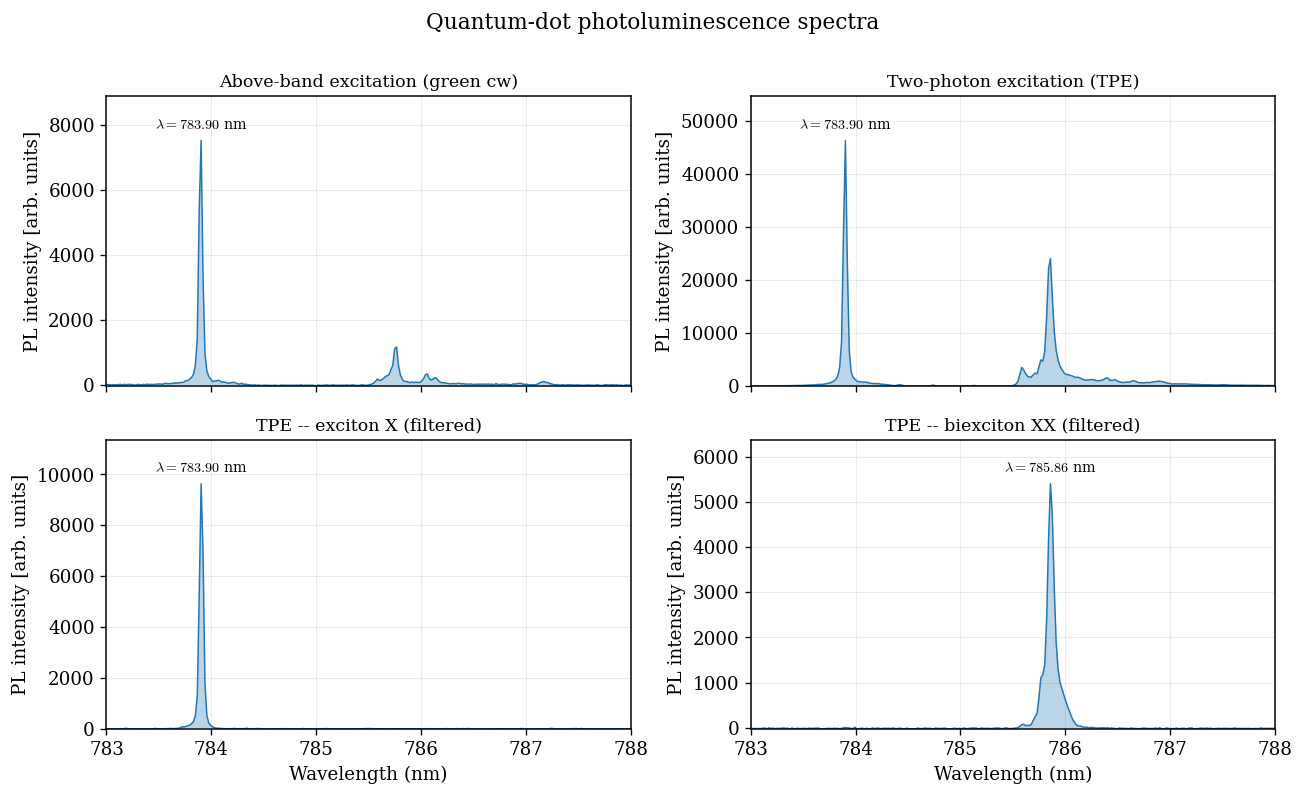

In [45]:
"""Load and plot the quantum-dot photoluminescence spectra."""

# CSV columns: wavelength (nm), counts, acquisition flag (unused).
SPECTRA_FILES = {
    "Above-band excitation (green cw)": "QD_Above_band_green_2s.csv",
    "Two-photon excitation (TPE)":      "QD_TPE_0.5S.csv",
    "TPE -- exciton X (filtered)":      "QD_TPE_X_filtered_2s.csv",
    "TPE -- biexciton XX (filtered)":   "QD_TPE_XX_filtered_2s.csv",
}


def load_spectrum(filename: str) -> tuple[np.ndarray, np.ndarray]:
    """Read one spectrometer CSV as (wavelength [nm], counts)."""
    table = np.genfromtxt(DATA_ROOT / "spectra" / filename, delimiter=",")
    return table[:, 0], table[:, 1]


def plot_spectra(save: bool = True):
    """Plot every photoluminescence spectrum on a shared 2x2 panel."""
    fig, axes = plt.subplots(2, 2, figsize=(11, 6.6), sharex=True)
    for ax, (title, filename) in zip(axes.flat, SPECTRA_FILES.items()):
        wavelength, counts = load_spectrum(filename)
        ax.fill_between(wavelength, counts, alpha=0.30, color="tab:blue", lw=0)
        ax.plot(wavelength, counts, lw=0.9, color="tab:blue")
        # Annotate the brightest line of each spectrum.
        peak = int(np.argmax(counts))
        ax.annotate(rf"$\lambda = {wavelength[peak]:.2f}$ nm",
                    xy=(wavelength[peak], counts[peak]),
                    xytext=(0, 7), textcoords="offset points",
                    ha="center", fontsize=8.5)
        # Headroom above the tallest line so the annotation never clips.
        ax.set_xlim(783, 788)
        ax.set_ylim(min(counts.min(), 0.0), counts.max() * 1.18)
        ax.set_title(title, fontsize=10.5)
        ax.set_ylabel("PL intensity [arb. units]")
        ax.margins(x=0.01)
    for ax in axes[-1]:
        ax.set_xlabel("Wavelength (nm)")
    fig.suptitle("Quantum-dot photoluminescence spectra", fontsize=13, y=1.00)
    fig.tight_layout()
    if save:
        save_figure(fig, "qd_emission_spectra")
    return fig, axes


fig_spectra, _ = plot_spectra()
plt.show()

## 3 &middot; Polarization states &amp; the POVM

<details>
<summary><b>&nbsp;Projectors, POVM elements and the POVM</b></summary>

Each photon is a polarization qubit in the $\{|H\rangle,|V\rangle\}$ basis.
A two-photon analyzer setting such as `HD` projects onto $|H\rangle\otimes|D\rangle$.
The associated **POVM element** is the rank-1 projector
$\Pi_{HD}=|HD\rangle\langle HD|$. The 16 settings `HH,HV,...,RL` build a
tomographically complete **POVM**: their projectors span the full space of
$4\times4$ Hermitian operators, so the density matrix can be reconstructed from
the 16 measured counts.

</details>


In [26]:
"""Single-photon kets, two-photon projectors, and reference Bell states."""

SQRT2 = np.sqrt(2.0)

# Single-photon polarization kets in the {|H>, |V>} computational basis.
POLARIZATION_KETS: dict[str, np.ndarray] = {
    "H": np.array([1.0,  0.0],  dtype=complex),   # horizontal
    "V": np.array([0.0,  1.0],  dtype=complex),   # vertical
    "D": np.array([1.0,  1.0],  dtype=complex) / SQRT2,   # diagonal
    "A": np.array([1.0, -1.0],  dtype=complex) / SQRT2,   # anti-diagonal
    "R": np.array([1.0, -1.0j], dtype=complex) / SQRT2,   # right-circular
    "L": np.array([1.0, +1.0j], dtype=complex) / SQRT2,   # left-circular
}

# The 16 analyzer settings of a tomographically complete two-photon measurement.
TOMOGRAPHY_LABELS = [
    "HH", "HV", "HD", "HL",
    "VH", "VV", "VD", "VL",
    "DH", "DV", "DD", "DR",
    "RH", "RV", "RD", "RL",
]

# Counts of these four settings define the normalization N = HH + HV + VH + VV.
NORMALIZATION_LABELS = ("HH", "HV", "VH", "VV")

# Labels of the two-photon computational basis, for plots and tables.
COMPUTATIONAL_BASIS = (r"$|HH\rangle$", r"$|HV\rangle$",
                       r"$|VH\rangle$", r"$|VV\rangle$")


def ket_from_label(label: str) -> np.ndarray:
    """Tensor two single-photon kets, e.g. 'HD' -> |H> (x) |D>."""
    ket = POLARIZATION_KETS[label[0]]
    for symbol in label[1:]:
        ket = np.kron(ket, POLARIZATION_KETS[symbol])
    return ket


def projector_from_label(label: str) -> np.ndarray:
    """Rank-1 projector |psi><psi| of a two-photon polarization ket."""
    ket = ket_from_label(label)
    return np.outer(ket, ket.conj())


# Maximally entangled Bell states, used as fidelity targets.
BELL_STATES: dict[str, np.ndarray] = {
    "Phi+": (ket_from_label("HH") + ket_from_label("VV")) / SQRT2,
    "Phi-": (ket_from_label("HH") - ket_from_label("VV")) / SQRT2,
    "Psi+": (ket_from_label("HV") + ket_from_label("VH")) / SQRT2,
    "Psi-": (ket_from_label("HV") - ket_from_label("VH")) / SQRT2,
}

In [27]:
"""Data structures: an integrated peak, a POVM element, and the full POVM."""


@dataclass
class PeakIntegration:
    """Outcome of integrating one peak of a TCSPC delay histogram."""
    counts: float          # background-subtracted integrated counts
    sigma: float           # Poisson uncertainty on `counts`
    raw_counts: float      # integrated counts before background subtraction
    background: float      # estimated background rate (counts per bin)
    threshold: float       # signal threshold = background + n_sigma * noise
    peak_time: float       # delay of the tallest bin (ps)
    peak_height: float     # counts in the tallest bin
    window: tuple          # (start, end) of the integration window (ps)
    n_bins: int            # number of bins inside the window
    search_window: tuple   # (lo, hi) delay region scanned for the peak (ps)


@dataclass
class POVMElement:
    """One POVM element: the rank-1 projector of a single analyzer setting,
    together with the photon counts measured for it."""
    label: str
    projector: np.ndarray
    coincidence: PeakIntegration | None = None   # central / true coincidence peak
    reference: PeakIntegration | None = None     # side peak (DOT normalization)

    @property
    def ket(self) -> np.ndarray:
        return ket_from_label(self.label)

    @property
    def scaling(self) -> float:
        """Element-specific scaling: the side-peak counts (DOT) or 1.0 (LASER)."""
        return self.reference.counts if self.reference is not None else 1.0

    @property
    def normalized_counts(self) -> float:
        """Coincidence counts rescaled by the element-specific factor."""
        if self.coincidence is None:
            return 0.0
        return self.coincidence.counts / max(self.scaling, 1e-12)

    def __repr__(self) -> str:
        return f"POVMElement({self.label!r}, normalized={self.normalized_counts:.4g})"


class POVM:
    """A tomographically complete POVM: the set of 16 polarization projectors
    {Pi_i} together with the counts measured for each of them."""

    def __init__(self, dataset: str, elements: list):
        self.dataset = dataset                       # "DOT" or "LASER"
        self.elements = elements
        self._by_label = {e.label: e for e in elements}

    def __getitem__(self, label: str) -> POVMElement:
        return self._by_label[label]

    def __iter__(self):
        return iter(self.elements)

    def __len__(self) -> int:
        return len(self.elements)

    def __repr__(self) -> str:
        return f"POVM(dataset={self.dataset!r}, elements={len(self.elements)})"

    @property
    def labels(self) -> list:
        return [e.label for e in self.elements]

    @property
    def projectors(self) -> np.ndarray:
        """Array of the 16 projector matrices, shape (16, 4, 4)."""
        return np.array([e.projector for e in self.elements])

    @property
    def normalized_counts(self) -> np.ndarray:
        return np.array([e.normalized_counts for e in self.elements])

    @property
    def normalization(self) -> float:
        """N = sum of normalized counts over HH, HV, VH, VV."""
        return float(sum(self[l].normalized_counts for l in NORMALIZATION_LABELS))

    @property
    def probabilities(self) -> np.ndarray:
        """Measured probabilities p_i = (normalized counts)_i / N."""
        return self.normalized_counts / self.normalization

## 4 &middot; Histogram processing &amp; count extraction

<details>
<summary><b>&nbsp;How a coincidence peak is integrated</b></summary>

Photon counts are **Poissonian**: a flat background of rate $b$ counts/bin has
per-bin noise $\sqrt{b}$. The integrator

1. locates the tallest bin inside a search window,
2. estimates $b$ from the bins outside a guard region around that peak,
3. flags as *signal* every bin above the threshold
   $b + n_\sigma\sqrt{b}$,
4. integrates the connected run of signal bins around the peak and subtracts
   the background $b$ under it.

The integrated, background-subtracted value is the counts of one POVM element.

**LASER** &mdash; one peak is integrated over the whole delay window.

**DOT** &mdash; under pulsed excitation the histogram has a *central* coincidence
peak (same excitation pulse) and *side* peaks one laser period away (different
pulses). The central peak is integrated inside a $\pm5$ ns window. A side peak
(always the same side for every setting) is integrated the same way; its counts
are the element-specific scaling factor that removes per-setting efficiency
drift &mdash; the *normalized counts* are central&nbsp;/&nbsp;side.

</details>


In [ ]:
"""Reading TCSPC histograms and integrating their peaks."""

# Geometry of the two datasets (all delays in picoseconds).
DATASET_CONFIG = {
    # LASER calibration: short window, a single peak, no side-peak normalization.
    "LASER": dict(central_half_window=np.inf, has_reference=False),
    # Quantum dot: long window, central coincidence peak + repetition side peaks.
    "DOT":   dict(central_half_window=5_000.0, has_reference=True,
                  reference_side="right", reference_gap=5_000.0),
}


def read_histogram(path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Read a two-column TCSPC file as (delay [ps], counts per bin)."""
    table = np.genfromtxt(path, skip_header=1)
    return table[:, 0], table[:, 1]


def integrate_peak(delays, counts, search_window, *,
                   guard_bins: int = 15, n_sigma: float = 3.0) -> PeakIntegration:
    """Locate and integrate the dominant peak inside `search_window`.

    Bins are flagged as signal when they exceed background + n_sigma*sqrt(background),
    the Poissonian noise floor. The connected run of signal bins around the
    tallest bin is integrated and the background under it is subtracted.
    """
    lo, hi = search_window
    inside = (delays >= lo) & (delays <= hi)
    d, c = delays[inside], counts[inside]
    span = (float(d[0]), float(d[-1]))

    peak = int(np.argmax(c))
    peak_height = float(c[peak])

    # Background rate from every bin outside a guard region around the peak.
    background_bins = np.ones(len(c), dtype=bool)
    background_bins[max(0, peak - guard_bins): peak + guard_bins + 1] = False
    background = float(np.mean(c[background_bins])) if background_bins.any() else 0.0
    noise = np.sqrt(background) # per bin noise
    threshold = background + n_sigma * noise

    if peak_height < threshold:                      # no statistically significant peak
        return PeakIntegration(0.0, 1.0, 0.0, background, threshold,
                               float(d[peak]), peak_height,
                               (float(d[peak]), float(d[peak])), 0, span)

    # Grow a connected window outward from the tallest bin while above threshold.
    left = right = peak
    while left > 0 and c[left - 1] >= threshold:
        left -= 1
    while right < len(c) - 1 and c[right + 1] >= threshold:
        right += 1

    n_bins = right - left + 1
    raw_counts = float(np.sum(c[left:right + 1]))
    signal = max(0.0, raw_counts - n_bins * background)
    # Poisson error: var(raw) + var(subtracted background) ~ raw + n_bins*background.
    sigma = float(np.sqrt(raw_counts + n_bins * background))
    
    bin_width = float(np.median(np.diff(d))) if len(d) > 1 else 1.0
    window = (float(d[left]) - bin_width / 2, float(d[right]) + bin_width / 2)
    return PeakIntegration(signal, sigma, raw_counts, background, threshold,
                           float(d[peak]), peak_height, window, n_bins, span)


def analyse_histogram(delays, counts, dataset: str, **peak_kwargs):
    """Integrate the coincidence peak (and, for DOT, the side peak) of a histogram."""
    cfg = DATASET_CONFIG[dataset]
    half = cfg["central_half_window"]
    coincidence = integrate_peak(delays, counts, (-half, half), **peak_kwargs)

    reference = None
    if cfg["has_reference"]:
        gap = cfg["reference_gap"]
        if cfg["reference_side"] == "right":
            side_window = (gap, float(delays.max()))
        else:
            side_window = (float(delays.min()), -gap)
        reference = integrate_peak(delays, counts, side_window, **peak_kwargs)
    return coincidence, reference


def load_povm(dataset: str, **peak_kwargs) -> POVM:
    """Build the POVM of a dataset folder, integrating all 16 histograms."""
    data_dir = DATA_ROOT / dataset
    elements = []
    for label in TOMOGRAPHY_LABELS:
        delays, counts = read_histogram(data_dir / f"{label}.txt")
        coincidence, reference = analyse_histogram(delays, counts, dataset,
                                                   **peak_kwargs)
        elements.append(POVMElement(label, projector_from_label(label),
                                    coincidence, reference))
    return POVM(dataset, elements)

## 5 &middot; Coincidence visualization

<details>
<summary><b>&nbsp;What the coincidence figure shows</b></summary>

For a chosen analyzer setting the figure shows, in one panel:

* the **full delay histogram** (log scale) with the integrated coincidence
  window shaded in orange &mdash; and, for DOT, the side-peak window in green;
* a **zoom on the background landscape**, with the detection threshold and the
  estimated background level, so the noise floor that defines the signal can be
  inspected directly;
* a **results box** listing the extracted counts, normalized counts and all the
  peak metadata.

</details>


In [29]:
"""Coincidence-histogram visualization for a single analyzer setting."""


def _shade_peak(ax, peak: PeakIntegration, *, color: str, label: str) -> None:
    """Shade an integration window and mark its peak position."""
    if peak is None or peak.n_bins == 0:
        return
    ax.axvspan(peak.window[0], peak.window[1], color=color, alpha=0.25, label=label)
    ax.axvline(peak.peak_time, color=color, lw=1.1, alpha=0.9)


def _plot_background_zoom(ax, delays, counts, peak: PeakIntegration) -> None:
    """Zoom on the noise floor around the peak, exposing the background features."""
    start, end = peak.window
    width = max(end - start, 200.0)
    lo, hi = start - 3 * width, end + 3 * width
    view = (delays >= lo) & (delays <= hi)

    ax.fill_between(delays[view], counts[view], step="mid", color="0.82", lw=0)
    ax.plot(delays[view], counts[view], drawstyle="steps-mid", lw=0.8, color="0.30")
    ax.axvspan(start, end, color="tab:orange", alpha=0.25)
    ax.axhline(peak.threshold, color="tab:red", ls="--", lw=1.2,
               label=f"threshold = {peak.threshold:.1f}")
    ax.axhline(peak.background, color="tab:blue", ls=":", lw=1.2,
               label=f"background = {peak.background:.2f}/bin")
    # Clip y so the background structure, not the tall peak, fills the panel.
    ax.set_ylim(0, max(4 * peak.threshold, 6))
    ax.set_xlim(lo, hi)
    ax.set_xlabel(r"Time delay $\tau$ (ps)")
    ax.set_ylabel("Counts per bin")
    ax.set_title("Background landscape near the detection threshold", fontsize=10)
    ax.legend(loc="upper right")


def _results_panel(ax, element: POVMElement) -> None:
    """Render the extracted-counts summary as a boxed text panel."""
    c = element.coincidence
    lines = [
        "EXTRACTED COUNTS",
        f"  projector       {element.label}",
        f"  peak delay      {c.peak_time:.0f} ps",
        f"  window          [{c.window[0]:.0f}, {c.window[1]:.0f}] ps",
        f"  bins            {c.n_bins}",
        f"  background      {c.background:.2f} counts/bin",
        f"  threshold       {c.threshold:.1f} counts",
        f"  raw counts      {c.raw_counts:.0f}",
        f"  coincidences    {c.counts:.0f} $\\pm$ {c.sigma:.0f}",
    ]
    if element.reference is not None:
        r = element.reference
        lines += [
            "",
            "SIDE-PEAK REFERENCE",
            f"  peak delay      {r.peak_time:.0f} ps",
            f"  side counts     {r.counts:.0f} $\\pm$ {r.sigma:.0f}",
        ]
    lines += [
        "",
        "NORMALIZED",
        f"  scaling factor  {element.scaling:.1f}",
        f"  norm. counts    {element.normalized_counts:.4f}",
    ]
    ax.axis("off")
    ax.text(0.0, 1.0, "\n".join(lines), transform=ax.transAxes,
            va="top", ha="left", family="monospace", fontsize=9.0,
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#f6f6f6", edgecolor="0.7"))


def plot_coincidence(povm: POVM, label: str, *, save: bool = False):
    """Plot the coincidence histogram and integration result for one setting."""
    element = povm[label]
    delays, counts = read_histogram(DATA_ROOT / povm.dataset / f"{label}.txt")

    fig = plt.figure(figsize=(12.5, 6.7))
    grid = GridSpec(2, 3, figure=fig, height_ratios=[1.35, 1.0],
                    hspace=0.36, wspace=0.32)
    ax_main = fig.add_subplot(grid[0, :])
    ax_zoom = fig.add_subplot(grid[1, :2])
    ax_info = fig.add_subplot(grid[1, 2])

    # --- full histogram (log scale reveals both the peaks and the floor) ------
    ax_main.plot(delays, counts, drawstyle="steps-mid", lw=0.7, color="0.30")
    _shade_peak(ax_main, element.coincidence, color="tab:orange",
                label="coincidence window")
    _shade_peak(ax_main, element.reference, color="tab:green",
                label="reference (side) window")
    ax_main.set_yscale("log")
    ax_main.set_ylim(bottom=0.8)
    ax_main.set_xlabel(r"Time delay $\tau$ (ps)")
    ax_main.set_ylabel("Counts per bin")
    ax_main.set_title(rf"{povm.dataset} -- POVM element "
                      rf"$\Pi_{{{label}}}=|{label}\rangle\langle {label}|$")
    ax_main.legend(loc="upper right", ncol=2)

    # --- zoom on the background + results panel -------------------------------
    _plot_background_zoom(ax_zoom, delays, counts, element.coincidence)
    _results_panel(ax_info, element)

    if save:
        save_figure(fig, f"coincidence_{povm.dataset}_{label}")
    return fig

## 6 &middot; Density-matrix reconstruction

<details>
<summary><b>&nbsp;Linear inversion</b></summary>

Expanding $\rho$ over the (non-orthogonal) projector basis, $\rho=\sum_j c_j\Pi_j$,
the Born rule $p_i=\mathrm{Tr}(\Pi_i\rho)$ becomes the linear system $p=Gc$ with the
**Gram matrix** $G_{ij}=\mathrm{Tr}(\Pi_i\Pi_j)$. Solving $Gc=p$ and resumming gives
$\rho$. Because the $\Pi_j$ are Hermitian and the $c_j$ real, $\rho$ is **Hermitian
by construction** &mdash; no symmetrization is needed. The estimate is exact but
**not** constrained to $\rho\succeq0$, so it can have small negative eigenvalues.

</details>

<details>
<summary><b>&nbsp;Maximum likelihood</b></summary>

To guarantee a physical state the density matrix is parametrized as

$$\rho(T)=\frac{T^\dagger T}{\mathrm{Tr}(T^\dagger T)},$$

with $T$ a **lower-triangular (Cholesky) matrix** with complex entries
(James, Kwiat, Munro &amp; White, *Phys. Rev. A* **64**, 052312, 2001).
$T^\dagger T$ is Hermitian and positive-semidefinite for any $T$, and the trace
normalizes it, so every $\rho(T)$ is a valid state. The triangular form has 16
real parameters (4 real diagonal + 6 complex sub-diagonal) and spans **all**
physical $4\times4$ density matrices &mdash; including the $|HH\rangle\!\leftrightarrow\!|VV\rangle$
coherence that defines a $\Phi^+$ Bell state.

The parameters are found by minimizing the **negative log-likelihood** of the
normalized counts $n_i$ given the model prediction $\nu_i=N\,p_i(\rho)$:

* *Poisson* &mdash; $\;\mathcal{L}=\sum_i\bigl[\nu_i-n_i\ln\nu_i\bigr]$,
* *Gaussian* &mdash; $\;\mathcal{L}=\sum_i\dfrac{(\nu_i-n_i)^2}{2\,\nu_i}$.

The minimization uses **L-BFGS-B** seeded from the linear-inversion estimate
(projected onto the nearest physical state), which lands close to the optimum
and converges in a few tens of iterations.

</details>


In [30]:
"""Reconstruction 1/2 -- linear inversion."""


def reconstruct_linear_inversion(povm: POVM) -> np.ndarray:
    """Reconstruct rho by linear inversion of the measured probabilities.

    Solves p = G c for the expansion coefficients of rho = sum_j c_j Pi_j, where
    G_ij = Tr(Pi_i Pi_j) is the Gram matrix of the projectors. rho is Hermitian
    by construction (real coefficients, Hermitian projectors) but is not forced
    to be positive-semidefinite.
    """
    projectors = povm.projectors
    probabilities = povm.probabilities
    # Gram matrix; Tr(Pi_i Pi_j) is real because the projectors are Hermitian.
    gram = np.array([[np.trace(A @ B).real for B in projectors]
                      for A in projectors])
    coefficients = np.linalg.solve(gram, probabilities)        # real solution
    rho = np.tensordot(coefficients, projectors, axes=(0, 0))
    return rho

In [31]:
"""Reconstruction 2/2 -- maximum likelihood with a physical (Cholesky) parametrization."""

# Lower-triangular T has 4 real diagonal entries and 6 complex sub-diagonal
# entries, i.e. 16 real parameters in total.
_T_SUBDIAGONAL = [(1, 0), (2, 0), (3, 0), (2, 1), (3, 1), (3, 2)]


def _params_to_T(x: np.ndarray) -> np.ndarray:
    """Pack 16 real parameters into a lower-triangular complex matrix T."""
    T = np.zeros((4, 4), dtype=complex)
    T[np.diag_indices(4)] = x[:4]
    for k, (i, j) in enumerate(_T_SUBDIAGONAL):
        T[i, j] = x[4 + 2 * k] + 1j * x[5 + 2 * k]
    return T


def _T_to_params(T: np.ndarray) -> np.ndarray:
    """Inverse of `_params_to_T`: flatten T into 16 real parameters."""
    x = np.empty(16)
    x[:4] = np.real(np.diag(T))
    for k, (i, j) in enumerate(_T_SUBDIAGONAL):
        x[4 + 2 * k], x[5 + 2 * k] = T[i, j].real, T[i, j].imag
    return x


def rho_from_T(T: np.ndarray) -> np.ndarray:
    """Physical density matrix rho = T^dag T / Tr(T^dag T): Hermitian, PSD, unit trace."""
    M = T.conj().T @ T
    return M / np.trace(M).real


def _cholesky_seed(rho: np.ndarray) -> np.ndarray:
    """Lower-triangular T with T^dag T approx rho, used to initialize the MLE fit."""
    # Project rho onto the PSD cone so the Cholesky factorization is well defined.
    eigvals, eigvecs = np.linalg.eigh((rho + rho.conj().T) / 2)
    rho_psd = (eigvecs * np.clip(eigvals, 1e-9, None)) @ eigvecs.conj().T
    rho_psd /= np.trace(rho_psd).real
    # Cholesky of the basis-reversed matrix yields a lower-triangular factor.
    flip = np.fliplr(np.eye(4))
    lower = np.linalg.cholesky(flip @ rho_psd @ flip)
    return flip @ lower.conj().T @ flip


def _negative_log_likelihood(x, projectors, counts, N, model) -> float:
    """Negative log-likelihood of the counts given rho(T(x))."""
    rho = rho_from_T(_params_to_T(x))
    p = np.einsum("ijk,kj->i", projectors, rho).real      # p_i = Tr(Pi_i rho)
    expected = N * np.clip(p, 1e-12, None)
    if model == "poisson":
        return float(np.sum(expected - counts * np.log(expected)))
    # Gaussian: chi-square with the Poisson variance approximated by the model.
    return float(np.sum((expected - counts) ** 2 / (2.0 * expected)))


def reconstruct_mle(povm: POVM, *, likelihood: str = "poisson",
                    optimizer: str = "L-BFGS-B", return_result: bool = False):
    """Maximum-likelihood density matrix, physical by construction (rho = T^dag T / Tr).

    The 16 real parameters of the lower-triangular factor T are fitted by
    minimizing the negative log-likelihood of the normalized counts, seeded
    from the (PSD-projected) linear-inversion estimate.
    """
    projectors = povm.projectors
    counts = povm.normalized_counts
    N = povm.normalization
    seed = _T_to_params(_cholesky_seed(reconstruct_linear_inversion(povm)))

    options = ({"maxiter": 20_000, "ftol": 1e-12, "gtol": 1e-10}
               if optimizer in ("L-BFGS-B", "BFGS")
               else {"maxiter": 50_000, "xatol": 1e-10, "fatol": 1e-12})
    result = opt.minimize(_negative_log_likelihood, seed,
                          args=(projectors, counts, N, likelihood),
                          method=optimizer, options=options)

    rho = rho_from_T(_params_to_T(result.x))
    return (rho, result) if return_result else rho

## 7 &middot; Metrics

<details>
<summary><b>&nbsp;The reported quantities</b></summary>

* $\mathrm{Tr}\,\rho$ &mdash; normalization check (should be 1).
* $\mathrm{Tr}\,\rho^2$ &mdash; **purity** (1 for a pure state, $1/4$ fully mixed).
* $F=\langle\psi|\rho|\psi\rangle$ &mdash; **fidelity** to a pure target state.
* $C$ &mdash; **Wootters concurrence** (0 separable, 1 maximally entangled).
* $\mathcal{N}$ &mdash; **negativity** from the partial transpose.
* $E_F$ &mdash; **entanglement of formation**, derived from $C$.

</details>


In [32]:
"""Density-matrix metrics: trace, purity, fidelity and entanglement measures."""

_SIGMA_Y = np.array([[0.0, -1j], [1j, 0.0]], dtype=complex)
_YY = np.kron(_SIGMA_Y, _SIGMA_Y)          # sigma_y (x) sigma_y, for the concurrence


def trace(rho: np.ndarray) -> float:
    """Tr(rho) -- a normalization check."""
    return float(np.real(np.trace(rho)))


def purity(rho: np.ndarray) -> float:
    """Tr(rho^2) -- the purity of the state."""
    return float(np.real(np.trace(rho @ rho)))


def fidelity(rho: np.ndarray, target_ket: np.ndarray) -> float:
    """State fidelity F = <psi|rho|psi> with a pure target |psi>."""
    psi = target_ket / np.linalg.norm(target_ket)
    return float(np.real(np.vdot(psi, rho @ psi)))


def concurrence(rho: np.ndarray) -> float:
    """Wootters concurrence of a two-qubit state (0 separable, 1 max. entangled)."""
    R = rho @ _YY @ rho.conj() @ _YY
    roots = np.sqrt(np.clip(np.real(np.linalg.eigvals(R)), 0.0, None))
    roots = np.sort(roots)[::-1]
    return float(max(0.0, roots[0] - roots[1] - roots[2] - roots[3]))


def negativity(rho: np.ndarray) -> float:
    """Negativity: sum of |negative eigenvalues| of the partial transpose."""
    partial_transpose = rho.reshape(2, 2, 2, 2).swapaxes(1, 3).reshape(4, 4)
    eigvals = np.linalg.eigvalsh(partial_transpose)
    return float(np.sum(np.abs(eigvals[eigvals < 0])))


def entanglement_of_formation(rho: np.ndarray) -> float:
    """Entanglement of formation of a two-qubit state, derived from the concurrence."""
    C = np.clip(concurrence(rho), 0.0, 1.0)
    if C == 0.0:
        return 0.0
    x = (1.0 + np.sqrt(1.0 - C ** 2)) / 2.0
    return float(-x * np.log2(x) - (1.0 - x) * np.log2(1.0 - x))


def eigenvalues(rho: np.ndarray) -> np.ndarray:
    """Eigenvalues of rho, sorted in descending order."""
    return np.sort(np.linalg.eigvalsh((rho + rho.conj().T) / 2))[::-1]


def state_metrics(rho: np.ndarray, target_ket: np.ndarray) -> dict:
    """Bundle the standard scalar diagnostics of a reconstructed density matrix."""
    return {
        "trace": trace(rho),
        "purity": purity(rho),
        "fidelity": fidelity(rho, target_ket),
        "concurrence": concurrence(rho),
        "negativity": negativity(rho),
        "entanglement_of_formation": entanglement_of_formation(rho),
    }


# Order and LaTeX symbols of the metrics, shared by the printout and the tables.
METRIC_SYMBOLS = {
    "trace": r"\mathrm{Tr}\,\rho",
    "purity": r"\mathrm{Tr}\,\rho^2",
    "fidelity": "F",
    "concurrence": "C",
    "negativity": r"\mathcal{N}",
    "entanglement_of_formation": "E_F",
}

## 8 &middot; Monte-Carlo uncertainty

<details>
<summary><b>&nbsp;Propagating the counting noise</b></summary>

The measured counts are Poisson random variables. To turn that into an
uncertainty on every metric we **resample**: for each POVM element a new count
is drawn from a Poisson distribution whose mean is the measured count (the
coincidence peak, and for DOT also the side peak). Each resampled POVM is
reconstructed &mdash; with the *same* estimator &mdash; and the metrics are
recomputed. The mean and the sample standard deviation (`ddof=1`) over the
samples are the reported value and error bar.

</details>


In [33]:
"""Poisson Monte-Carlo propagation of the counting noise onto the metrics."""


def _resample_povm(povm: POVM, rng: np.random.Generator) -> POVM:
    """Return a copy of the POVM with Poisson-resampled coincidence counts.

    Each measured count is an independent Poisson variable, so we redraw the
    coincidence peak (and, for DOT, the side peak) around its measured value.
    """
    resampled = []
    for element in povm:
        coincidence = replace(
            element.coincidence,
            counts=float(rng.poisson(max(element.coincidence.counts, 0.0))),
        )
        reference = element.reference
        if reference is not None:
            reference = replace(
                reference, counts=float(rng.poisson(max(reference.counts, 1.0))),
            )
        resampled.append(replace(element, coincidence=coincidence,
                                 reference=reference))
    return POVM(povm.dataset, resampled)


def monte_carlo_metrics(povm: POVM, target_ket, *,
                        reconstruct=reconstruct_linear_inversion,
                        n_samples: int = 500, seed: int = 0) -> dict:
    """Estimate the mean and std (ddof=1) of every metric by Poisson resampling."""
    rng = np.random.default_rng(seed)
    samples = {key: [] for key in METRIC_SYMBOLS}
    for _ in range(n_samples):
        rho = reconstruct(_resample_povm(povm, rng))
        for key, value in state_metrics(rho, target_ket).items():
            samples[key].append(value)
    return {key: {"mean": float(np.mean(values)),
                  "std": float(np.std(values, ddof=1))}
            for key, values in samples.items()}

## 9 &middot; Density-matrix plot, tables &amp; saving


In [34]:
"""3D 'city-plot' visualization of a 4x4 density matrix."""


def _bar3d_panel(ax, values: np.ndarray, title: str, zlim: tuple) -> None:
    """Draw one 3D bar panel for either the real or the imaginary part of rho."""
    n = values.shape[0]
    xpos, ypos = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
    heights = values.reshape(-1)
    width = 0.62
    # Blue for positive entries, red for negative -- standard in QST papers.
    colors = np.where(heights >= 0, "#3b6fb6", "#c0392b")
    ax.bar3d(xpos.ravel() - width / 2, ypos.ravel() - width / 2,
             np.zeros(n * n), width, width, heights,
             color=colors, edgecolor="black", linewidth=0.35, alpha=0.92, shade=True)
    ax.set_title(title, pad=10)
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(COMPUTATIONAL_BASIS, rotation=40, ha="right", fontsize=9)
    ax.set_yticklabels(COMPUTATIONAL_BASIS, rotation=-25, ha="left", fontsize=9)
    ax.set_zlim(*zlim)
    ax.view_init(elev=26, azim=-50)
    ax.set_box_aspect((1, 1, 0.62))


def plot_density_matrix(rho: np.ndarray, *, title: str = r"\rho",
                        save_as: str | None = None):
    """Plot Re(rho) and Im(rho) side by side as 3D bar charts."""
    fig = plt.figure(figsize=(12, 5.3))
    zmax = max(0.55, float(np.abs(rho).max()) * 1.05)
    ax_real = fig.add_subplot(1, 2, 1, projection="3d")
    ax_imag = fig.add_subplot(1, 2, 2, projection="3d")
    _bar3d_panel(ax_real, np.real(rho), rf"$\mathrm{{Re}}\,{title}$", (-0.12, zmax))
    _bar3d_panel(ax_imag, np.imag(rho), rf"$\mathrm{{Im}}\,{title}$",
                 (-zmax / 2, zmax / 2))
    fig.subplots_adjust(left=0.03, right=0.97, top=0.92, bottom=0.04, wspace=0.06)
    if save_as:
        save_figure(fig, save_as)
    return fig

In [35]:
"""LaTeX tables, a plain-text report, and a JSON dump of the results."""


def latex_counts_table(povm: POVM, *, print_table: bool = True) -> str:
    """LaTeX table of the integrated counts of every POVM element."""
    rows = [r"\begin{tabular}{lccc}", r"\hline",
            r"Setting & Coincidences $N\pm\sigma_N$ & Norm. counts & Window (ps) \\",
            r"\hline"]
    for element in povm:
        c = element.coincidence
        rows.append(rf"{element.label} & ${c.counts:.0f}\pm{c.sigma:.0f}$ & "
                    rf"{element.normalized_counts:.4f} & "
                    rf"$[{c.window[0]:.0f},\,{c.window[1]:.0f}]$ \\")
    rows += [r"\hline", r"\end{tabular}"]
    table = "\n".join(rows)
    if print_table:
        print(table)
    return table


def latex_metrics_table(metrics: dict, mc: dict | None = None, *,
                         print_table: bool = True) -> str:
    """LaTeX table of the density-matrix metrics, with Monte-Carlo errors if given."""
    rows = [r"\begin{tabular}{lc}", r"\hline", r"Metric & Value \\", r"\hline"]
    for key, symbol in METRIC_SYMBOLS.items():
        if key not in metrics:
            continue
        if mc and key in mc:
            rows.append(rf"${symbol}$ & ${metrics[key]:.4f}\pm{mc[key]['std']:.4f}$ \\")
        else:
            rows.append(rf"${symbol}$ & ${metrics[key]:.4f}$ \\")
    rows += [r"\hline", r"\end{tabular}"]
    table = "\n".join(rows)
    if print_table:
        print(table)
    return table


def print_metrics_report(title: str, metrics: dict, evals: np.ndarray,
                         mc: dict | None = None) -> None:
    """Print a readable summary of the metrics of a reconstructed state."""
    print(title)
    print("-" * len(title))
    for key in METRIC_SYMBOLS:
        value = metrics[key]
        if mc and key in mc:
            print(f"  {key:26s} = {value:9.4f}  +/- {mc[key]['std']:.4f}")
        else:
            print(f"  {key:26s} = {value:9.4f}")
    print(f"  {'eigenvalues(rho)':26s} = "
          f"[{', '.join(f'{e:+.4f}' for e in evals)}]")
    print()


def rho_to_serializable(rho: np.ndarray) -> dict:
    """Split a complex matrix into JSON-friendly real and imaginary parts."""
    return {"real": np.real(rho).tolist(), "imag": np.imag(rho).tolist()}


def save_results(name: str, *, counts_table: str | None = None,
                 metrics_table: str | None = None,
                 payload: dict | None = None) -> None:
    """Persist tables (.tex) and a results summary (.json) under results/."""
    if counts_table is not None:
        (TABLE_DIR / f"{name}_counts.tex").write_text(counts_table)
    if metrics_table is not None:
        (TABLE_DIR / f"{name}_metrics.tex").write_text(metrics_table)
    if payload is not None:
        (RESULTS_DIR / f"{name}.json").write_text(json.dumps(payload, indent=2))
    print(f"  saved results for '{name}' under {RESULTS_DIR}/")

# Inference &mdash; running the pipeline

<details>
<summary><b>&nbsp;How to run</b></summary>

Everything above only *defines* functions. The cells below *run* the analysis.
Set `DATASET` to `"DOT"` for the entangled quantum-dot photon pairs, or to
`"LASER"` to repeat the same pipeline on the laser calibration dataset
(a separable $|HH\rangle$ state). All figures and tables are written to
`results/`.

</details>


### 10 &middot; Load the data and build the POVM


In [46]:
# Dataset to analyse: "DOT" (entangled photon pairs) or "LASER" (calibration).
DATASET = "LASER"

# Target pure state for the fidelity: Phi+ Bell state for DOT, |HH> for LASER.
TARGET_KET = {"DOT": BELL_STATES["Phi+"], "LASER": ket_from_label("HH")}[DATASET]
TARGET_NAME = {"DOT": r"\Phi^+", "LASER": "HH"}[DATASET]

# Build the POVM: read the 16 histograms and integrate every coincidence peak.
povm = load_povm(DATASET)
print(povm)
print(f"target state for fidelity: |{TARGET_NAME}>")
povm.elements

POVM(dataset='LASER', elements=16)
target state for fidelity: |HH>


[POVMElement('HH', normalized=5.047e+05),
 POVMElement('HV', normalized=409.4),
 POVMElement('HD', normalized=2.396e+05),
 POVMElement('HL', normalized=2.59e+05),
 POVMElement('VH', normalized=195.2),
 POVMElement('VV', normalized=0),
 POVMElement('VD', normalized=66),
 POVMElement('VL', normalized=93),
 POVMElement('DH', normalized=2.785e+05),
 POVMElement('DV', normalized=261.9),
 POVMElement('DD', normalized=1.279e+05),
 POVMElement('DR', normalized=1.303e+05),
 POVMElement('RH', normalized=2.789e+05),
 POVMElement('RV', normalized=216.2),
 POVMElement('RD', normalized=1.268e+05),
 POVMElement('RL', normalized=1.42e+05)]

### 11 &middot; Count extraction &amp; coincidence plots


In [47]:
# Table of the integrated counts of every POVM element.
counts_table = latex_counts_table(povm)

\begin{tabular}{lccc}
\hline
Setting & Coincidences $N\pm\sigma_N$ & Norm. counts & Window (ps) \\
\hline
HH & $504651\pm711$ & 504650.5444 & $[-310,\,250]$ \\
HV & $409\pm20$ & 409.3964 & $[-90,\,70]$ \\
HD & $239615\pm490$ & 239614.9408 & $[-310,\,230]$ \\
HL & $259045\pm509$ & 259045.3018 & $[-310,\,230]$ \\
VH & $195\pm14$ & 195.1893 & $[-70,\,110]$ \\
VV & $0\pm0$ & 0.0000 & $[-2010,\,1990]$ \\
VD & $66\pm8$ & 66.0000 & $[-2010,\,1990]$ \\
VL & $93\pm10$ & 93.0000 & $[-2010,\,1990]$ \\
DH & $278522\pm528$ & 278522.2544 & $[-310,\,230]$ \\
DV & $262\pm16$ & 261.8817 & $[-90,\,50]$ \\
DD & $127935\pm358$ & 127935.3195 & $[-290,\,210]$ \\
DR & $130258\pm361$ & 130257.7692 & $[-290,\,230]$ \\
RH & $278869\pm529$ & 278869.1716 & $[-310,\,230]$ \\
RV & $216\pm15$ & 216.1538 & $[-90,\,70]$ \\
RD & $126824\pm356$ & 126824.0592 & $[-290,\,210]$ \\
RL & $141994\pm377$ & 141993.8462 & $[-310,\,210]$ \\
\hline
\end{tabular}


  saved  results/figures/coincidence_LASER_HH.{png,pdf}
  saved  results/figures/coincidence_LASER_VH.{png,pdf}


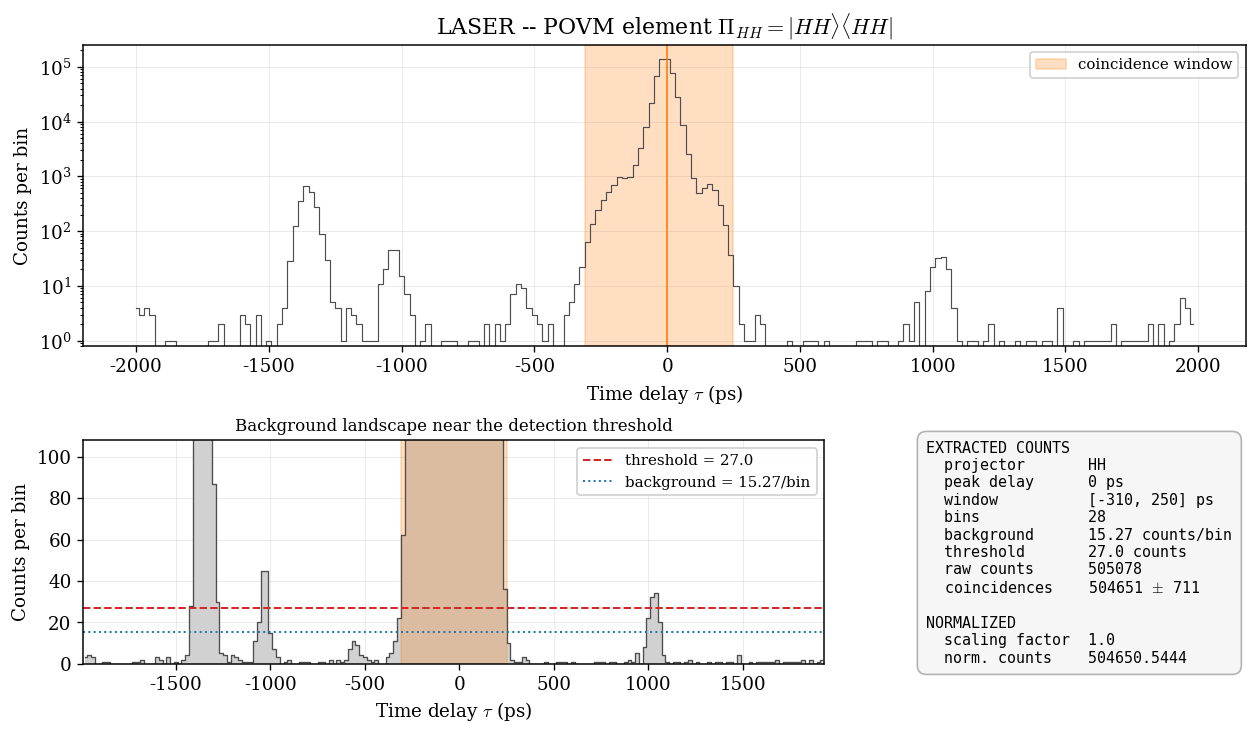

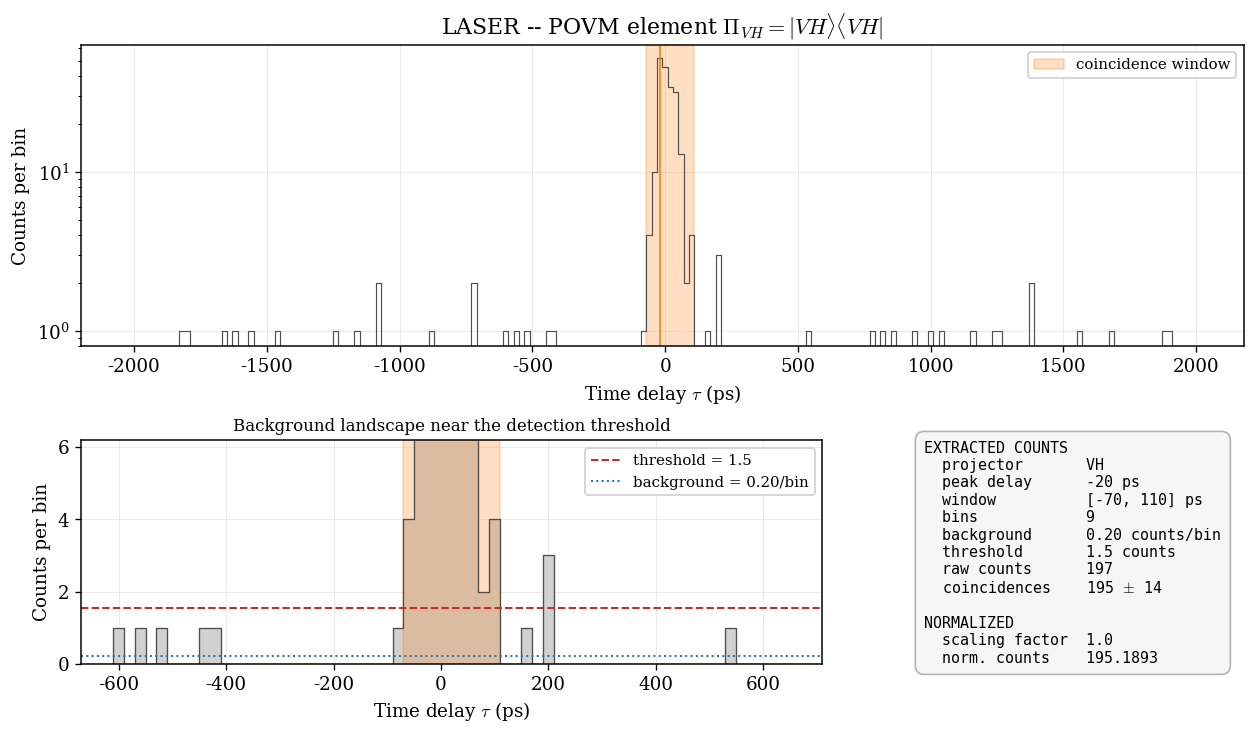

In [48]:
# Inspect the peak integration for a few representative analyzer settings.
# 'HH' is the brightest coincidence; 'RL' is a low-count, low-SNR setting.
for label in ("HH", "VH"):
    plot_coincidence(povm, label, save=True)
plt.show()

### 12 &middot; Reconstruction by linear inversion


Linear inversion
----------------
  trace                      =    1.0000
  purity                     =    1.0116
  fidelity                   =    0.9988
  concurrence                =    0.0000
  negativity                 =    0.0272
  entanglement_of_formation  =    0.0000
  eigenvalues(rho)           = [+1.0057, +0.0047, -0.0010, -0.0094]

  saved  results/figures/density_matrix_LASER_linear_inversion.{png,pdf}


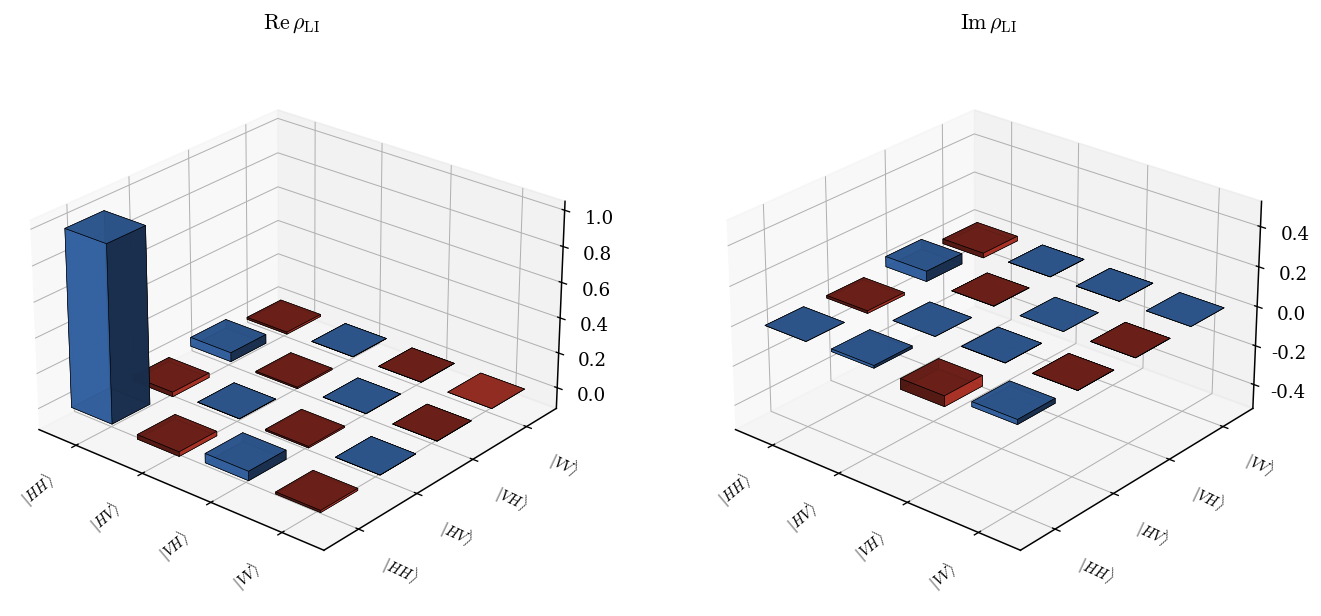

In [49]:
rho_li = reconstruct_linear_inversion(povm)
metrics_li = state_metrics(rho_li, TARGET_KET)
evals_li = eigenvalues(rho_li)

print_metrics_report("Linear inversion", metrics_li, evals_li)
plot_density_matrix(rho_li, title=r"\rho_{\mathrm{LI}}",
                    save_as=f"density_matrix_{DATASET}_linear_inversion")
plt.show()

### 13 &middot; Reconstruction by maximum likelihood


MLE fit: success=True, iterations=133, -logL=-23942286.1105

Maximum likelihood (Poisson)
----------------------------
  trace                      =    1.0000
  purity                     =    0.9999
  fidelity                   =    0.9979
  concurrence                =    0.0055
  negativity                 =    0.0027
  entanglement_of_formation  =    0.0001
  eigenvalues(rho)           = [+1.0000, +0.0000, +0.0000, +0.0000]

  saved  results/figures/density_matrix_LASER_mle.{png,pdf}


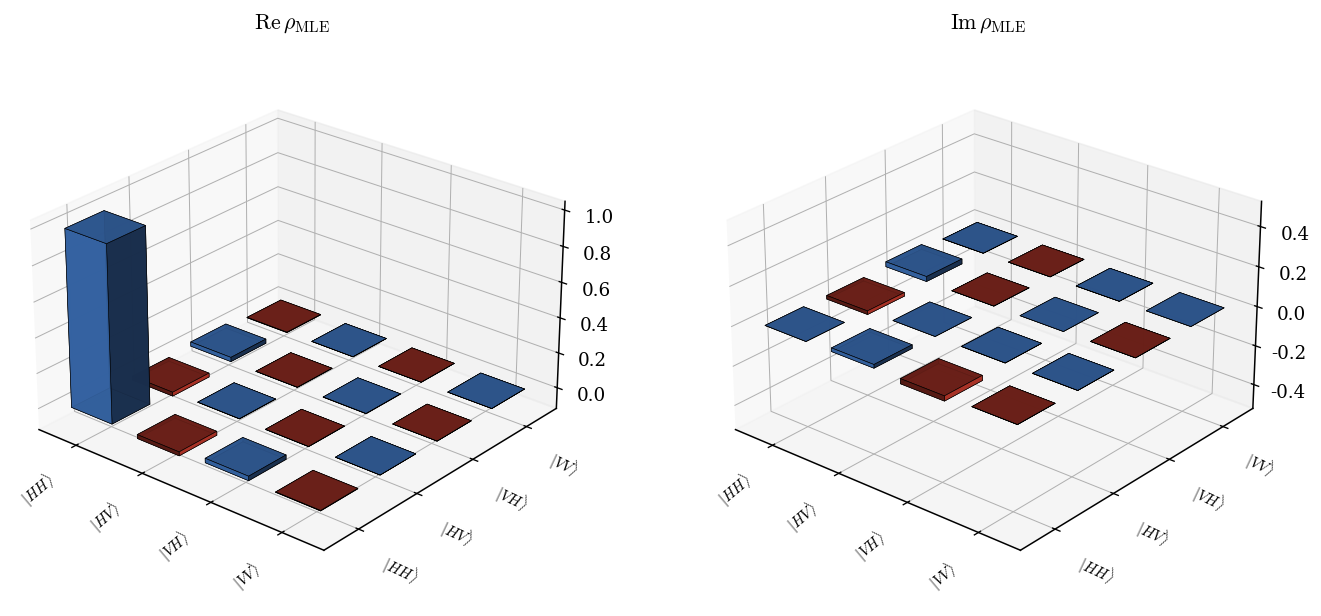

In [50]:
rho_mle, fit = reconstruct_mle(povm, likelihood="poisson", return_result=True)
metrics_mle = state_metrics(rho_mle, TARGET_KET)
evals_mle = eigenvalues(rho_mle)

print(f"MLE fit: success={fit.success}, iterations={fit.nit}, "
      f"-logL={fit.fun:.4f}\n")
print_metrics_report("Maximum likelihood (Poisson)", metrics_mle, evals_mle)
plot_density_matrix(rho_mle, title=r"\rho_{\mathrm{MLE}}",
                    save_as=f"density_matrix_{DATASET}_mle")
plt.show()

### 14 &middot; Uncertainties &amp; final results

The Poisson Monte-Carlo below resamples the measured counts and propagates the
counting noise through *both* estimators, giving the error bar on every metric.
All tables and a JSON summary are then written to `results/`.


In [51]:
# Poisson Monte-Carlo: error bars on the metrics for both estimators.
mc_li = monte_carlo_metrics(povm, TARGET_KET,
                            reconstruct=reconstruct_linear_inversion,
                            n_samples=800, seed=1)
mc_mle = monte_carlo_metrics(povm, TARGET_KET,
                             reconstruct=lambda p: reconstruct_mle(p),
                             n_samples=300, seed=1)

print_metrics_report("Linear inversion  (value +/- Poisson MC std)",
                     metrics_li, evals_li, mc=mc_li)
print_metrics_report("Maximum likelihood (value +/- Poisson MC std)",
                     metrics_mle, evals_mle, mc=mc_mle)

Linear inversion  (value +/- Poisson MC std)
--------------------------------------------
  trace                      =    1.0000  +/- 0.0000
  purity                     =    1.0116  +/- 0.0006
  fidelity                   =    0.9988  +/- 0.0000
  concurrence                =    0.0000  +/- 0.0000
  negativity                 =    0.0272  +/- 0.0017
  entanglement_of_formation  =    0.0000  +/- 0.0000
  eigenvalues(rho)           = [+1.0057, +0.0047, -0.0010, -0.0094]

Maximum likelihood (value +/- Poisson MC std)
---------------------------------------------
  trace                      =    1.0000  +/- 0.0000
  purity                     =    0.9999  +/- 0.0001
  fidelity                   =    0.9979  +/- 0.0001
  concurrence                =    0.0055  +/- 0.0024
  negativity                 =    0.0027  +/- 0.0012
  entanglement_of_formation  =    0.0001  +/- 0.0001
  eigenvalues(rho)           = [+1.0000, +0.0000, +0.0000, +0.0000]



In [52]:
# Assemble the LaTeX metrics tables and persist everything under results/.
metrics_table_li = latex_metrics_table(metrics_li, mc_li, print_table=False)
metrics_table_mle = latex_metrics_table(metrics_mle, mc_mle, print_table=False)

save_results(
    f"{DATASET}_linear_inversion",
    counts_table=counts_table, metrics_table=metrics_table_li,
    payload={
        "dataset": DATASET, "estimator": "linear_inversion",
        "target_state": TARGET_NAME,
        "normalized_counts": dict(zip(povm.labels, povm.normalized_counts.tolist())),
        "metrics": metrics_li,
        "metrics_uncertainty": mc_li,
        "rho": rho_to_serializable(rho_li),
    },
)
save_results(
    f"{DATASET}_mle",
    metrics_table=metrics_table_mle,
    payload={
        "dataset": DATASET, "estimator": "maximum_likelihood",
        "target_state": TARGET_NAME, "likelihood": "poisson",
        "metrics": metrics_mle,
        "metrics_uncertainty": mc_mle,
        "rho": rho_to_serializable(rho_mle),
    },
)
print("\nLaTeX metrics table (MLE):\n")
print(metrics_table_mle)

  saved results for 'LASER_linear_inversion' under results/
  saved results for 'LASER_mle' under results/

LaTeX metrics table (MLE):

\begin{tabular}{lc}
\hline
Metric & Value \\
\hline
$\mathrm{Tr}\,\rho$ & $1.0000\pm0.0000$ \\
$\mathrm{Tr}\,\rho^2$ & $0.9999\pm0.0001$ \\
$F$ & $0.9979\pm0.0001$ \\
$C$ & $0.0055\pm0.0024$ \\
$\mathcal{N}$ & $0.0027\pm0.0012$ \\
$E_F$ & $0.0001\pm0.0001$ \\
\hline
\end{tabular}


### Summary

The two estimators agree within the Monte-Carlo error bars. **Linear inversion**
is exact but can return a slightly unphysical $\rho$ (purity $>1$, small negative
eigenvalues) because positivity is not enforced. **Maximum likelihood** returns a
physical state ($\rho\succeq0$, unit trace) at the cost of a small bias, and is
the result to quote.

All figures (PNG + PDF) and tables (LaTeX + JSON) are saved under `results/`.
To re-run the calibration, set `DATASET = "LASER"` in section 10 and execute the
inference cells again.
